In [2]:
import xgboost

In [3]:
xgboost.__version__

'3.1.3'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
)

import xgboost as xgb

## Load and Prepare Data

We load the dataset from `uci_bank_data.csv` and perform data cleaning and preprocessing

#### **Client-related attributes:**
- `age`: Age of the client (numeric)
- `job`: Type of job (categorical: e.g., admin., technician, unemployed)
- `marital`: Marital status (categorical: married, single, divorced)
- `education`: Education level (categorical: e.g., primary, secondary, tertiary)
- `default`: Has credit in default? (binary: yes/no)
- `balance`: Average yearly balance in euros (numeric)
- `housing`: Has housing loan? (binary: yes/no)
- `loan`: Has personal loan? (binary: yes/no)

#### **Campaign-related attributes:**
- `contact`: Contact communication type (categorical: cellular, telephone)
- `day`: Last contact day of the month (numeric)
- `month`: Last contact month (categorical)
- `duration`: Last contact duration in seconds (numeric)
  **(Important: This feature is highly predictive but should be handled carefully in model building.)**

#### **Previous campaign attributes:**
- `campaign`: Number of contacts during this campaign (numeric)
- `pdays`: Days since last contact in a previous campaign (-1 means never contacted)
- `previous`: Number of contacts before this campaign (numeric)
- `poutcome`: Outcome of the previous campaign (categorical)

---

### **Output Variable**
- `y`: Has the client subscribed to a term deposit? (binary: yes/no)

In [11]:
bank_data = pd.read_csv('../datasets/uci_bank_data.csv')

In [12]:
bank_data.shape

(45211, 17)

In [13]:
bank_data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [14]:
bank_data = bank_data.drop(columns=['duration'])

In [15]:
bank_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,-1,0,unknown,no


In [16]:
bank_data['target'] = bank_data.pop('y').map({'no': 0, 'yes': 1})
bank_data.sample(n=5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,target
2905,49,entrepreneur,married,secondary,no,348,yes,no,unknown,14,may,2,-1,0,unknown,0
35959,24,services,single,secondary,no,281,yes,no,cellular,8,may,2,337,3,other,0
43268,71,retired,married,primary,no,2171,no,no,cellular,10,mar,4,-1,0,unknown,0
15237,29,services,married,secondary,no,23,no,no,cellular,17,jul,4,-1,0,unknown,0
1215,46,blue-collar,married,primary,no,45,yes,no,unknown,8,may,1,-1,0,unknown,0


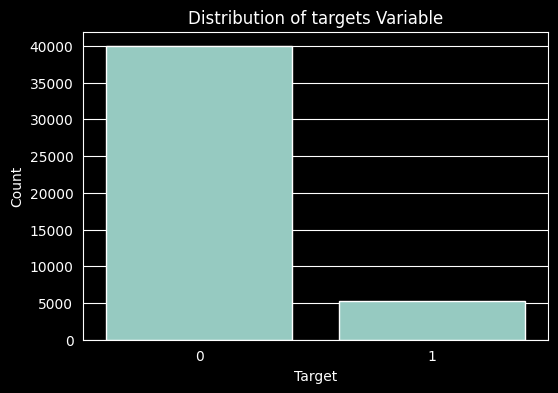

In [18]:
target_counts = bank_data['target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)

ax.set_xlabel('Target')
ax.set_ylabel('Count')
ax.set_title('Distribution of targets Variable')

plt.show()

In [19]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  campaign   45211 non-null  int64 
 12  pdays      45211 non-null  int64 
 13  previous   45211 non-null  int64 
 14  poutcome   45211 non-null  object
 15  target     45211 non-null  int64 
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


In [21]:
categorical_variables = bank_data.select_dtypes(exclude=np.number).columns.tolist()
categorical_variables

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [22]:
bank_data[categorical_variables] = bank_data[categorical_variables].astype('category')
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  campaign   45211 non-null  int64   
 12  pdays      45211 non-null  int64   
 13  previous   45211 non-null  int64   
 14  poutcome   45211 non-null  category
 15  target     45211 non-null  int64   
dtypes: category(9), int64(7)
memory usage: 2.8 MB


In [23]:
X = bank_data.drop('target', axis=1)
y = bank_data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train.shape, X_test.shape

((31647, 15), (13564, 15))

In [25]:
xgb_clf = xgb.XGBClassifier(
    booster='gbtree',
    n_estimators=300,
    enable_categorical=True,
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='auc',
    random_state=42,
)

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Evaluation Metrics:
Accuracy: 0.8904
Precision: 0.5637
Recall: 0.2817
F1 Score: 0.3756


In [27]:
from collections import Counter

In [28]:
counts = Counter(y_train)
scale = counts[0] / counts[1]
scale

7.548622366288493

In [29]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
scale

np.float64(7.548622366288493)

In [30]:
xgb_clf = xgb.XGBClassifier(
    booster='gbtree',
    n_estimators=300,
    enable_categorical=True,
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='auc',
    scale_pos_weight=scale,
    random_state=42,
)

xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

In [31]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Evaluation Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Evaluation Metrics:
Accuracy: 0.8538
Precision: 0.3898
Recall: 0.4411
F1 Score: 0.4138


In [35]:
importances = xgb_clf.feature_importances_
features = X.columns

feature_importances_df = pd.DataFrame({
    'Feature': features,
    'Importances': importances,
}).sort_values(by='Importances', ascending=False)

feature_importances_df

,Feature,Importances
14,poutcome,0.261771
8,contact,0.116258
6,housing,0.094421
10,month,0.084538
7,loan,0.050513
1,job,0.050151
2,marital,0.046065
9,day,0.044955
0,age,0.039353
4,default,0.037820


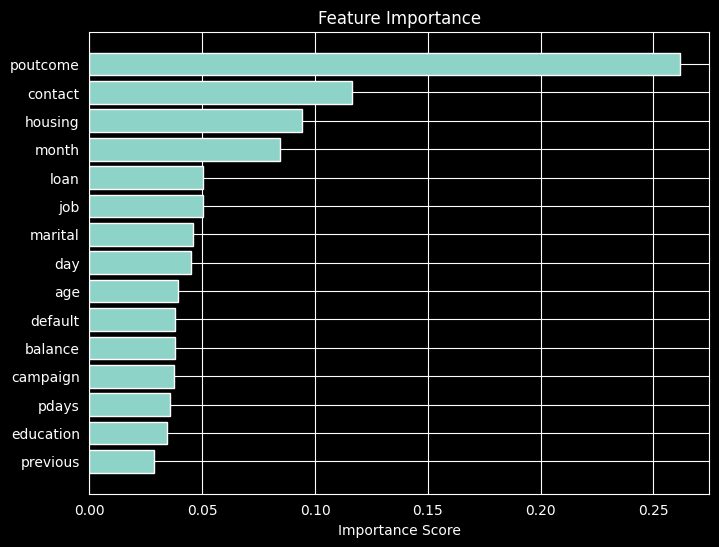

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    feature_importances_df["Feature"],
    feature_importances_df["Importances"]
)

ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance")

ax.invert_yaxis()

plt.show()

In [41]:
def train_evaluate_model(params):
    model = xgb.XGBClassifier(
        booster='gbtree',
        n_estimators=300,
        enable_categorical=True,
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='auc',
        scale_pos_weight=scale,
        random_state=42,
        **params
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1



In [42]:
params_list = [
    {'gamma': 0, 'reg_lambda': 1, 'reg_alpha': 0},
    {'gamma': 0.1, 'reg_lambda': 2, 'reg_alpha': 1},
    {'gamma': 0.3, 'reg_lambda': 2, 'reg_alpha': 0.5},
]

In [43]:
results = []

for params in params_list:
    acc, prec, rec, fls = train_evaluate_model(params)
    results.append({
        'Parameters': params,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': fls,
    })

results_df = pd.DataFrame(results)
results_df

,Parameters,Accuracy,Precision,Recall,F1 Score
0,"{'gamma': 0, 'reg_lambda': 1, 'reg_alpha': 0}",0.853804,0.389755,0.441084,0.413834
1,"{'gamma': 0.1, 'reg_lambda': 2, 'reg_alpha': 1}",0.853141,0.391537,0.460618,0.423277
2,"{'gamma': 0.3, 'reg_lambda': 2, 'reg_alpha': 0.5}",0.839354,0.370289,0.532451,0.436805


In [44]:
# Early Stopping

# Early Stopping

In [45]:
X_train_es, X_val, y_train_es, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

X_train_es.shape, X_val.shape, X_test.shape

((25317, 15), (6330, 15), (13564, 15))

In [46]:
d_train = xgb.DMatrix(X_train_es, label=y_train_es, enable_categorical=True)
d_val = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
d_test = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [47]:
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'scale_pos_weight': scale,
    'random_state': 42
}

In [48]:
model = xgb.train(
    params,
    d_train,
    num_boost_round=300,
    evals=[(d_val, 'validation')],
    early_stopping_rounds=10,
    verbose_eval=True,
)

[0]	validation-auc:0.75216
[1]	validation-auc:0.76933
[2]	validation-auc:0.77730
[3]	validation-auc:0.78746
[4]	validation-auc:0.78597
[5]	validation-auc:0.78864
[6]	validation-auc:0.78843
[7]	validation-auc:0.78542
[8]	validation-auc:0.78698
[9]	validation-auc:0.79032
[10]	validation-auc:0.78825
[11]	validation-auc:0.78734
[12]	validation-auc:0.78376
[13]	validation-auc:0.78311
[14]	validation-auc:0.78471
[15]	validation-auc:0.78354
[16]	validation-auc:0.78269
[17]	validation-auc:0.78272
[18]	validation-auc:0.78226
[19]	validation-auc:0.78348


In [49]:
y_pred_es = model.predict(d_test)
y_pred_es = [round(value) for value in y_pred_es]

accuracy = accuracy_score(y_test, y_pred_es)
precision = precision_score(y_test, y_pred_es)
recall = recall_score(y_test, y_pred_es)
f1 = f1_score(y_test, y_pred_es)

print("Evaluation Metrics:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Evaluation Metrics:
Accuracy: 0.8219
Precision: 0.3506
Recall: 0.6131
F1 Score: 0.4461


### Cross validation

In [50]:
d_train = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
d_test = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

In [53]:
params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'scale_pos_weight': scale,
    'random_state': 42
}

results = xgb.cv(
    params,
    d_train,
    nfold=5,
    num_boost_round=30,
)

results

,train-auc-mean,train-auc-std,test-auc-mean,test-auc-std
0,0.772374,0.002845,0.748937,0.009550
1,0.789500,0.002613,0.764666,0.011221
2,0.801197,0.002813,0.777304,0.011722
3,0.809052,0.002907,0.783197,0.011822
4,0.815132,0.002268,0.786704,0.010074
5,0.820021,0.003775,0.786668,0.011605
6,0.826000,0.003313,0.788068,0.013267
7,0.830323,0.002872,0.789007,0.013311
8,0.835849,0.003705,0.790329,0.014152
9,0.842499,0.004145,0.790134,0.014104


In [52]:
type(results)

pandas.core.frame.DataFrame

In [54]:
xgb_clf1 = xgb.XGBClassifier(
    device='cuda',
    booster='gbtree',
    n_estimators=300,
    enable_categorical=True,
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='auc',
    scale_pos_weight=scale,
    random_state=42,
)

xgb_clf1.fit(X_train, y_train)
y_pred = xgb_clf1.predict(X_test)

/home/lipov/projects/ensamble_learning/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:01:32] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/home/lipov/projects/ensamble_learning/.venv/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [13:01:32] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
